# STEP 1 — Load & Transform Dataset

## Imports

In [1]:
import nltk
import re
import numpy as np
import pandas as pd
import torch
from nltk.corpus import stopwords
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
# nltk.download('punkt')
# nltk.download('punkt_tab')
# nltk.download('stopwords')

## Parse JSON Files

In [2]:
import json
import os

def load_dataset(path):
    dataset = []
    
    for file in os.listdir(path):
        if file.endswith(".json"):
            file_path = os.path.join(path, file)
            
            with open(file_path, encoding="utf-8") as f:
                data = json.load(f)

                for article in data.get("data", []):
                    for para in article.get("paragraphs", []):
                        context = para.get("context", "")

                        for qa in para.get("qas", []):
                            question = qa.get("question", "")
                            answers = qa.get("answers", [])

                            if answers:
                                answer = answers[0].get("text", "")
                                
                                dataset.append({
                                    "question": question,
                                    "context": context,
                                    "answer": answer
                                })
    
    return dataset
    

## Inspect Data

In [3]:
data = load_dataset("data")

print(f"\nTotal examples loaded: {len(data)}")
if data:
    print("\nFirst example:")
    print(json.dumps(data[0], indent=2, ensure_ascii=False))


Total examples loaded: 240

First example:
{
  "question": "ما الحدث الذي جعل أورسون ويلز مشهورًا قبل دخوله السينما؟",
  "context": "في ليلة 30 أكتوبر 1938، انقطع بث إذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لأن الناس صدقوا الخبر. لاحقًا تبيّن أن الحدث كان تمثيلية إذاعية من إخراج أورسون ويلز. هذه التجربة أثبتت قدرته على التأثير في الجمهور.",
  "answer": "تمثيلية إذاعية عن غزو فضائي"
}


# STEP 2 — Preprocessing

## Cleaning

In [4]:
# def remove_stopwords_and_punctuation_from_text(text):
#     nltk_stop_words = set(stopwords.words('arabic'))


#     # punctuation ='!"$%&()*,-./:;<=>?@[\\]^_`{|}~'
#     punctuation = [
#     "،","؛","؟","ـ","«","»","‹","›","“","”","‘","’",
#     ".",",",";",":","!","?","-","_","(",")","[","]","{","}",
#     "\"","'","/","\\","|","@","#","$","%","^","&","*","+","=","<",">","~","`","``","''"
#     ]
#     for p in punctuation:
#         text = text.replace(p, '')

#     tokens = nltk.word_tokenize(text)

#     filtered_tokens = [
#         word for word in tokens 
#         if word not in nltk_stop_words 
#         and not re.search(r'[a-zA-Z]', word)]   # remove words containing English letters
#     # Join the tokens back into a string
#     filtered_text = ' '.join(filtered_tokens)
#     return filtered_text

In [5]:
# for item in data:
#     item['question'] = remove_stopwords_and_punctuation_from_text(item['question'])
#     item['context'] = remove_stopwords_and_punctuation_from_text(item['context'])
#     item['answer'] = remove_stopwords_and_punctuation_from_text(item['answer'])

## Normalization

In [6]:
import re

def normalize_text(text):
    
    # 1. Convert English letters to lowercase
    text = text.lower()
    
    # 2. Remove Arabic Tashkeel (diacritics)
    tashkeel = r'[\u0617-\u061A\u064B-\u0652]'
    text = re.sub(tashkeel, '', text)

    # 3. Normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ة", "ه", text)
    text = re.sub("گ", "ك", text)

    # 4. Remove Tatweel (ـ)
    text = re.sub("ـ", "", text)

    return text

In [7]:
for item in data:
    item['question'] = normalize_text(item['question'])
    item['context'] = normalize_text(item['context'])
    item['answer'] = normalize_text(item['answer'])

# STEP 3 — Tokenization

## Tokenize

### Approach 1

In [8]:
# def tokenize(text):
#     return text.split()

### Approach 2

In [9]:
tokenizer = Tokenizer(
    num_words=20000,
    split=' ',
    char_level=False,
    oov_token="<OOV>"
  )

In [10]:
all_texts = []

for item in data:
    all_texts.append(item['question'])
    all_texts.append(item['context'])
    all_texts.append(item['answer'])

all_texts = [text for text in all_texts if text and isinstance(text, str)]
tokenizer.fit_on_texts(all_texts)

## Encode Text

### Approach 1

In [11]:
# def encode(text, vocab, max_len=100):
#     tokens = tokenize(text)
#     ids = [vocab.get(t, vocab["<unk>"]) for t in tokens]

#     # padding
#     ids = ids[:max_len]
#     ids += [vocab["<pad>"]] * (max_len - len(ids))

#     return ids

In [12]:
# ### Encode the dataset with answers also encoded
# encoded_data = []
# for item in data:
#     encoded_item = {
#         "question": encode(item["question"], vocab),
#         "context": encode(item["context"], vocab),
#         "answer": encode(item["answer"], vocab)
#     }
#     encoded_data.append(encoded_item)


### Approach 2

In [13]:
# max_question_len = 0
# max_context_len = 0
# max_answer_len = 0

# for item in data:
#     q_tokens = len(tokenizer.texts_to_sequences([item['question']])[0]) if 'question' in item else 0
#     c_tokens = len(tokenizer.texts_to_sequences([item['context']])[0])  if 'context' in item else 0
#     a_tokens = len(tokenizer.texts_to_sequences([item['answer']])[0])    if 'answer' in item else 0
    
#     max_question_len = max(max_question_len, q_tokens)
#     max_context_len  = max(max_context_len, c_tokens)
#     max_answer_len   = max(max_answer_len, a_tokens)

# print(f"Maximum Question Length: {max_question_len} tokens")
# print(f"Maximum Context Length : {max_context_len} tokens")
# print(f"Maximum Answer Length  : {max_answer_len} tokens")

In [14]:
MAX_Q_LEN = 30
MAX_C_LEN = 150
MAX_A_LEN = 15

q_seq = []
c_seq = []
a_seq = []

for item in data:
    q_seq.append(tokenizer.texts_to_sequences([item['question']])[0])
    c_seq.append(tokenizer.texts_to_sequences([item['context']])[0])
    a_seq.append(tokenizer.texts_to_sequences([item['answer']])[0])

q_seq = pad_sequences(q_seq, maxlen=MAX_Q_LEN, padding='post')
c_seq = pad_sequences(c_seq, maxlen=MAX_C_LEN, padding='post')
a_seq = pad_sequences(a_seq, maxlen=MAX_A_LEN, padding='post')

In [15]:
max(len(seq) for seq in a_seq)

15

## Build Vocabulary

### Approach 1

In [16]:
# from collections import Counter

# def build_vocab(data, min_freq=2):
#     counter = Counter()

#     for item in data:
#         counter.update(tokenize(item["question"]))
#         counter.update(tokenize(item["context"]))

#     vocab = {"<pad>": 0, "<unk>": 1}

#     for word, freq in counter.items():
#         if freq >= min_freq:
#             vocab[word] = len(vocab)

#     return vocab

In [17]:
# vocab = build_vocab(data)
# print(f"Vocabulary size: {len(vocab)}")

### Approach 2

In [18]:
# use this to get insight on the Tokenizer
word_index = tokenizer.word_index
vocab_size = len(word_index) + 1

## PyTorch Dataset

In [19]:
q_tensor = torch.tensor(q_seq)
c_tensor = torch.tensor(c_seq)
a_tensor = torch.tensor(a_seq)

In [20]:
from torch.utils.data import Dataset

class QADataset(Dataset):
    def __init__(self, q, c, a):
        self.q = q
        self.c = c
        self.a = a

    def __len__(self):
        return len(self.q)

    def __getitem__(self, idx):
        return self.q[idx], self.c[idx], self.a[idx]

## DataLoader

### Source Encoding For QA Pair
This cell builds the encoder source sequence as `[Q] question [SEP] [C] context` so both question and context are explicitly represented before entering the Transformer.

In [21]:
from torch.utils.data import DataLoader, random_split

BASE_VOCAB_SIZE = vocab_size
PAD_IDX = 0
SOS_IDX = BASE_VOCAB_SIZE
EOS_IDX = BASE_VOCAB_SIZE + 1
SEP_IDX = BASE_VOCAB_SIZE + 2
Q_IDX = BASE_VOCAB_SIZE + 3
C_IDX = BASE_VOCAB_SIZE + 4
TOTAL_VOCAB_SIZE = BASE_VOCAB_SIZE + 5

MAX_SRC_LEN = MAX_Q_LEN + MAX_C_LEN + 3  # [Q] question [SEP] [C] context
MAX_TGT_LEN = MAX_A_LEN + 2

dataset = QADataset(q_tensor.long(), c_tensor.long(), a_tensor.long())
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_ds, val_ds = random_split(
    dataset, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

def qa_collate(batch):
    q_batch, c_batch, a_batch = zip(*batch)
    q_batch = torch.stack(q_batch)
    c_batch = torch.stack(c_batch)
    a_batch = torch.stack(a_batch)

    q_tag = torch.full((q_batch.size(0), 1), Q_IDX, dtype=torch.long)
    sep_column = torch.full((q_batch.size(0), 1), SEP_IDX, dtype=torch.long)
    c_tag = torch.full((q_batch.size(0), 1), C_IDX, dtype=torch.long)
    src = torch.cat([q_tag, q_batch, sep_column, c_tag, c_batch], dim=1)[:, :MAX_SRC_LEN]

    sos_column = torch.full((a_batch.size(0), 1), SOS_IDX, dtype=torch.long)
    eos_column = torch.full((a_batch.size(0), 1), EOS_IDX, dtype=torch.long)
    a_trim = a_batch[:, :MAX_A_LEN]
    tgt_full = torch.cat([sos_column, a_trim, eos_column], dim=1)[:, :MAX_TGT_LEN]

    tgt_inp = tgt_full[:, :-1]
    tgt_out = tgt_full[:, 1:]
    return src, tgt_inp, tgt_out

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=qa_collate)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, collate_fn=qa_collate)

print(f"train samples: {len(train_ds)}")
print(f"val samples: {len(val_ds)}")
print(f"total vocabulary (with special tokens): {TOTAL_VOCAB_SIZE}")

train samples: 192
val samples: 48
total vocabulary (with special tokens): 2387


In [22]:
import math
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [23]:
idx_to_word = tokenizer.index_word

def decode_ids(ids, drop_special=True):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx == PAD_IDX:
            continue
        if idx == SOS_IDX:
            if not drop_special:
                words.append("<sos>")
            continue
        if idx == EOS_IDX:
            if not drop_special:
                words.append("<eos>")
            break
        if idx == SEP_IDX:
            if not drop_special:
                words.append("<sep>")
            continue
        if idx == Q_IDX:
            if not drop_special:
                words.append("<q>")
            continue
        if idx == C_IDX:
            if not drop_special:
                words.append("<c>")
            continue
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words)

print("example question:", data[0]["question"] if data else "N/A")
print("example answer:", data[0]["answer"] if data else "N/A")

example question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
example answer: تمثيليه اذاعيه عن غزو فضائي


In [24]:
# Confirm one batch shape after the 80/20 split and collate pipeline.
src_b, tgt_inp_b, tgt_out_b = next(iter(train_loader))
print("src batch:", tuple(src_b.shape))
print("tgt input batch:", tuple(tgt_inp_b.shape))
print("tgt output batch:", tuple(tgt_out_b.shape))

src batch: (32, 183)
tgt input batch: (32, 16)
tgt output batch: (32, 16)


### Positional Encoding
This cell adds positional signals to token embeddings so the model can distinguish token order in question, context, and generated answer sequences.

In [25]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)]
        return self.dropout(x)

### Scaled Dot-Product Attention
This is the core attention operation that computes attention weights between queries and keys, then aggregates values (with causal and padding masks).

In [26]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, q, k, v, attn_mask=None, key_padding_mask=None):
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask == 0, -1e9)

        if key_padding_mask is not None:
            # key_padding_mask: [B, T_k], True indicates PAD positions to ignore.
            scores = scores.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), -1e9
            )

        attn = torch.softmax(scores, dim=-1)
        return torch.matmul(attn, v), attn

### Multi-Head Attention
This cell splits attention into multiple heads so the model can learn different alignment patterns in parallel, then concatenates them back.

In [27]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_k = d_model // n_heads
        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.fc = nn.Linear(d_model, d_model)
        self.attn_mod = ScaledDotProductAttention()
        self.last_attention = None

    def forward(self, query, key, value, attn_mask=None, key_padding_mask=None):
        B, T_q, D = query.shape
        T_k = key.size(1)
        H, d_k = self.n_heads, self.d_k

        Q = self.w_q(query).view(B, T_q, H, d_k).transpose(1, 2)
        K = self.w_k(key).view(B, T_k, H, d_k).transpose(1, 2)
        V = self.w_v(value).view(B, T_k, H, d_k).transpose(1, 2)

        out, attn = self.attn_mod(
            Q, K, V, attn_mask=attn_mask, key_padding_mask=key_padding_mask
        )
        self.last_attention = attn
        out = out.transpose(1, 2).contiguous().view(B, T_q, D)
        return self.fc(out)


def causal_mask(size, device):
    return torch.tril(torch.ones(size, size, device=device)).bool()


def pad_key_mask(ids, pad_idx):
    return ids == pad_idx

### Encoder Layer (Self-Attention + Residual)
This encoder block applies self-attention over the source tokens, then a feed-forward network, both wrapped with residual connections and layer normalization.

In [28]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1, use_residual=True):
        super().__init__()
        self.use_residual = use_residual
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, src_key_padding_mask):
        attn_out = self.self_attn(
            x, x, x, attn_mask=None, key_padding_mask=src_key_padding_mask
        )
        if self.use_residual:
            x = self.norm1(x + self.dropout(attn_out))
        else:
            x = self.norm1(self.dropout(attn_out))

        ff_out = self.ff(x)
        if self.use_residual:
            x = self.norm2(x + self.dropout(ff_out))
        else:
            x = self.norm2(self.dropout(ff_out))
        return x

### Decoder Layer (Self-Attention + Cross-Attention + Residual)
This decoder block uses masked self-attention over generated tokens, then cross-attention to encoder outputs (question+context), followed by feed-forward, each with residual paths.

In [29]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ff_dim=256, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads)
        self.cross_attn = MultiHeadAttention(d_model, n_heads)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
        )

    def forward(self, x, enc_out, tgt_mask, src_key_padding_mask, tgt_key_padding_mask=None):
        self_attn_out = self.self_attn(
            x,
            x,
            x,
            attn_mask=tgt_mask,
            key_padding_mask=tgt_key_padding_mask,
        )
        x = self.norm1(x + self.dropout(self_attn_out))

        cross_attn_out = self.cross_attn(
            x,
            enc_out,
            enc_out,
            attn_mask=None,
            key_padding_mask=src_key_padding_mask,
        )
        x = self.norm2(x + self.dropout(cross_attn_out))

        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))
        return x

### Full Transformer Initialization
This cell initializes the main Transformer attributes: embeddings, positional encoders, encoder, decoder, and output projection layer for vocabulary logits.

In [30]:
class Transformer(nn.Module):
    def __init__(
        self,
        src_vocab,
        tgt_vocab,
        d_model=128,
        n_heads=4,
        ff_dim=256,
        dropout=0.2,
        use_residual_encoder=True,
        use_positional_encoding=True,
    ):
        super().__init__()
        self.d_model = d_model
        self.use_positional_encoding = use_positional_encoding
        self.src_emb = nn.Embedding(src_vocab, d_model, padding_idx=PAD_IDX)
        self.tgt_emb = nn.Embedding(tgt_vocab, d_model, padding_idx=PAD_IDX)
        self.pos_src = PositionalEncoding(d_model, max_len=MAX_SRC_LEN, dropout=dropout)
        self.pos_tgt = PositionalEncoding(d_model, max_len=MAX_TGT_LEN, dropout=dropout)
        self.encoder = EncoderLayer(
            d_model, n_heads, ff_dim=ff_dim, dropout=dropout, use_residual=use_residual_encoder
        )
        self.decoder = DecoderLayer(d_model, n_heads, ff_dim=ff_dim, dropout=dropout)
        self.fc = nn.Linear(d_model, tgt_vocab)

    def embed_src(self, src):
        x = self.src_emb(src) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_src(x)
        return x

    def embed_tgt(self, tgt):
        x = self.tgt_emb(tgt) * math.sqrt(self.d_model)
        if self.use_positional_encoding:
            x = self.pos_tgt(x)
        return x

    def forward(self, src, tgt):
        src_key_padding_mask = pad_key_mask(src, PAD_IDX)
        tgt_key_padding_mask = pad_key_mask(tgt, PAD_IDX)
        tgt_mask = causal_mask(tgt.size(1), tgt.device)

        enc = self.encoder(
            self.embed_src(src), src_key_padding_mask=src_key_padding_mask
        )
        dec = self.decoder(
            self.embed_tgt(tgt),
            enc,
            tgt_mask=tgt_mask,
            src_key_padding_mask=src_key_padding_mask,
            tgt_key_padding_mask=tgt_key_padding_mask,
        )
        return self.fc(dec)

In [31]:
def trace_shapes(model, src_b, tgt_b):
    model.eval()
    B, T_src = src_b.shape
    _, T_tgt = tgt_b.shape
    D = model.d_model
    H = model.encoder.self_attn.n_heads
    dk = D // H
    print(f"B={B}, T_src={T_src}, T_tgt={T_tgt}, D={D}, H={H}, d_k={dk}")
    with torch.no_grad():
        src_pad = pad_key_mask(src_b, PAD_IDX)
        emb_s = model.embed_src(src_b)
        print(f"embed_src out:        {tuple(emb_s.shape)}")
        enc = model.encoder(emb_s, src_key_padding_mask=src_pad)
        print(f"encoder out:          {tuple(enc.shape)}")
        tgt_mask = causal_mask(T_tgt, tgt_b.device)
        tgt_pad = pad_key_mask(tgt_b, PAD_IDX)
        emb_t = model.embed_tgt(tgt_b)
        print(f"embed_tgt out:        {tuple(emb_t.shape)}")
        dec = model.decoder(emb_t, enc, tgt_mask, src_pad, tgt_pad)
        print(f"decoder out:          {tuple(dec.shape)}")
        logits = model.fc(dec)
        print(f"lm logits:            {tuple(logits.shape)}")
        print(
            "inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)"
        )

src_batch, tgt_input_batch, _ = next(iter(train_loader))
src_1 = src_batch[:1].to(device)
tgt_1 = tgt_input_batch[:1].to(device)
trace_shapes(Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE).to(device), src_1, tgt_1)

B=1, T_src=183, T_tgt=16, D=128, H=4, d_k=32
embed_src out:        (1, 183, 128)
encoder out:          (1, 183, 128)
embed_tgt out:        (1, 16, 128)
decoder out:          (1, 16, 128)
lm logits:            (1, 16, 2387)
inside MHA, Q/K/V are reshaped to (B, H, T, d_k) and attention scores are (B, H, T_q, T_k)


In [39]:
import copy

def evaluate_loss(model, loader, loss_fn):
    model.eval()
    total_loss = 0.0
    total_batches = 0
    with torch.no_grad():
        for src, tgt_inp, tgt_out in loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)
            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
            total_loss += loss.item()
            total_batches += 1
    return total_loss / max(total_batches, 1)


def train_model(
    model,
    train_loader,
    val_loader,
    epochs=20,
    lr=7e-4,
    clip_grad=1.0,
    weight_decay=1e-4,
    patience=6,
    min_delta=1e-3,
    label_smoothing=0.1,
    return_batch_losses=False,
    ):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=2
    )
    loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=label_smoothing)

    history = []
    batch_losses = [] if return_batch_losses else None

    best_val_loss = float("inf")
    best_state = None
    no_improve_epochs = 0

    for epoch in range(epochs):
        model.train()
        running = 0.0
        n_batches = 0

        for src, tgt_inp, tgt_out in train_loader:
            src = src.to(device)
            tgt_inp = tgt_inp.to(device)
            tgt_out = tgt_out.to(device)

            logits = model(src, tgt_inp)
            loss = loss_fn(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad)
            optimizer.step()

            running += loss.item()
            n_batches += 1
            if return_batch_losses:
                batch_losses.append(loss.item())

        train_loss = running / max(n_batches, 1)
        val_loss = evaluate_loss(model, val_loader, loss_fn)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        history.append({"train_loss": train_loss, "val_loss": val_loss, "lr": current_lr})
        print(
            f"epoch {epoch + 1}/{epochs} - lr: {current_lr:.6f} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f}"
        )

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= patience:
                print(
                    f"Early stopping at epoch {epoch + 1}; best val_loss: {best_val_loss:.4f}"
                )
                break

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"Restored best model with val_loss: {best_val_loss:.4f}")

    if return_batch_losses:
        return history, batch_losses
    return history


model = Transformer(TOTAL_VOCAB_SIZE, TOTAL_VOCAB_SIZE, dropout=0.2).to(device)
history = train_model(
    model, train_loader, val_loader, epochs=40, lr=7e-4, patience=6, label_smoothing=0.1
)
epochs_ran = len(history)
best_val = min(h['val_loss'] for h in history) if history else float('nan')
print(f"Training summary: epochs_ran={epochs_ran}, best_val_loss={best_val:.4f}")

epoch 1/40 - lr: 0.000700 - train_loss: 7.6799 - val_loss: 7.1717
epoch 2/40 - lr: 0.000700 - train_loss: 6.8567 - val_loss: 6.8859
epoch 3/40 - lr: 0.000700 - train_loss: 6.4413 - val_loss: 6.7816
epoch 4/40 - lr: 0.000700 - train_loss: 6.1161 - val_loss: 6.6691
epoch 5/40 - lr: 0.000700 - train_loss: 5.8204 - val_loss: 6.6014
epoch 6/40 - lr: 0.000700 - train_loss: 5.6085 - val_loss: 6.5683
epoch 7/40 - lr: 0.000700 - train_loss: 5.4356 - val_loss: 6.5603
epoch 8/40 - lr: 0.000700 - train_loss: 5.2994 - val_loss: 6.5598
epoch 9/40 - lr: 0.000700 - train_loss: 5.1416 - val_loss: 6.5106
epoch 10/40 - lr: 0.000700 - train_loss: 5.0112 - val_loss: 6.4990
epoch 11/40 - lr: 0.000700 - train_loss: 4.8579 - val_loss: 6.4638
epoch 12/40 - lr: 0.000700 - train_loss: 4.7241 - val_loss: 6.4287
epoch 13/40 - lr: 0.000700 - train_loss: 4.5974 - val_loss: 6.4008
epoch 14/40 - lr: 0.000700 - train_loss: 4.4681 - val_loss: 6.3542
epoch 15/40 - lr: 0.000700 - train_loss: 4.3441 - val_loss: 6.3515
epoc

In [40]:
@torch.no_grad()
def greedy_decode(model, src_ids, max_len=MAX_TGT_LEN):
    model.eval()
    src_ids = src_ids.unsqueeze(0).to(device)
    ys = torch.tensor([[SOS_IDX]], device=device, dtype=torch.long)

    for _ in range(max_len - 1):
        logits = model(src_ids, ys)
        next_id = logits[:, -1, :].argmax(dim=-1, keepdim=True)
        ys = torch.cat([ys, next_id], dim=1)
        if next_id.item() == EOS_IDX:
            break
    return ys[0].cpu().tolist()


def decode_answer(ids):
    words = []
    for idx in ids:
        idx = int(idx)
        if idx in (PAD_IDX, SOS_IDX, SEP_IDX, Q_IDX, C_IDX):
            continue
        if idx == EOS_IDX:
            break
        words.append(idx_to_word.get(idx, "<unk>"))
    return " ".join(words).strip()


def encode_text_fixed(text, max_len):
    seq = tokenizer.texts_to_sequences([text])[0]
    seq = seq[:max_len] + [PAD_IDX] * max(0, max_len - len(seq))
    return seq[:max_len]


def build_src_from_text(question, context):
    q_ids = torch.tensor(encode_text_fixed(question, MAX_Q_LEN), dtype=torch.long)
    c_ids = torch.tensor(encode_text_fixed(context, MAX_C_LEN), dtype=torch.long)
    q_tag = torch.tensor([Q_IDX], dtype=torch.long)
    sep = torch.tensor([SEP_IDX], dtype=torch.long)
    c_tag = torch.tensor([C_IDX], dtype=torch.long)
    src = torch.cat([q_tag, q_ids, sep, c_tag, c_ids], dim=0)
    return src[:MAX_SRC_LEN]


def answer_question(model, question, context):
    src = build_src_from_text(question, context)
    out_ids = greedy_decode(model, src)
    return decode_answer(out_ids)


# Demo on one example from the original dataframe/list after training
demo_q = data[0]["question"] if data else ""
demo_c = data[0]["context"] if data else ""
demo_ref = data[0]["answer"] if data else ""
print("question:", demo_q)
print("context:", demo_c)
print("reference:", demo_ref)
print("prediction:", answer_question(model, demo_q, demo_c))

question: ما الحدث الذي جعل اورسون ويلز مشهورا قبل دخوله السينما؟
context: في ليله 30 اكتوبر 1938، انقطع بث اذاعي ليعلن عن غزو فضائي في نيوجيرسي. تسبب ذلك في ذعر واسع لان الناس صدقوا الخبر. لاحقا تبين ان الحدث كان تمثيليه اذاعيه من اخراج اورسون ويلز. هذه التجربه اثبتت قدرته علي التاثير في الجمهور.
reference: تمثيليه اذاعيه عن غزو فضائي
prediction: تمثيليه اذاعيه عن غزو فضائي في فلوريدا تشكيلات في فلوريدا تشكيلات في فلوريدا تشكيلات في فلوريدا


In [41]:
@torch.no_grad()
def teacher_forcing_token_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    for src, tgt_inp, tgt_out in loader:
        src = src.to(device)
        tgt_inp = tgt_inp.to(device)
        tgt_out = tgt_out.to(device)
        logits = model(src, tgt_inp)
        pred = logits.argmax(dim=-1)
        mask = tgt_out != PAD_IDX
        correct += (pred[mask] == tgt_out[mask]).sum().item()
        total += mask.sum().item()
    return correct / max(total, 1)


def token_f1(pred_text, ref_text):
    pred_tokens = pred_text.split()
    ref_tokens = ref_text.split()
    if not pred_tokens and not ref_tokens:
        return 1.0
    if not pred_tokens or not ref_tokens:
        return 0.0

    pred_set = {}
    for t in pred_tokens:
        pred_set[t] = pred_set.get(t, 0) + 1
    ref_set = {}
    for t in ref_tokens:
        ref_set[t] = ref_set.get(t, 0) + 1

    overlap = 0
    for t, c in pred_set.items():
        overlap += min(c, ref_set.get(t, 0))

    precision = overlap / max(len(pred_tokens), 1)
    recall = overlap / max(len(ref_tokens), 1)
    if precision + recall == 0:
        return 0.0
    return 2 * precision * recall / (precision + recall)


@torch.no_grad()
def evaluate_generation(model, dataset_split, max_samples=120):
    model.eval()
    n = min(len(dataset_split), max_samples)
    exact_match = 0
    f1_total = 0.0

    for i in range(n):
        q_ids, c_ids, a_ids = dataset_split[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred = decode_answer(pred_ids)
        ref = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])

        if pred == ref:
            exact_match += 1
        f1_total += token_f1(pred, ref)

    if n == 0:
        return 0.0, 0.0
    return exact_match / n, f1_total / n


train_acc = teacher_forcing_token_accuracy(model, train_loader)
val_acc = teacher_forcing_token_accuracy(model, val_loader)
em, f1 = evaluate_generation(model, val_ds, max_samples=100)
print(f"Train token accuracy: {train_acc:.4f}")
print(f"Validation token accuracy: {val_acc:.4f}")
print(f"Validation Exact Match: {em:.4f}")
print(f"Validation token-F1: {f1:.4f}")

Train token accuracy: 0.9637
Validation token accuracy: 0.3912
Validation Exact Match: 0.0000
Validation token-F1: 0.0466


In [42]:
@torch.no_grad()
def show_hard_validation_examples(model, subset, n_examples=10):
    model.eval()
    rows = []
    total = len(subset)

    for i in range(total):
        q_ids, c_ids, a_ids = subset[i]
        q_tag = torch.tensor([Q_IDX])
        sep = torch.tensor([SEP_IDX])
        c_tag = torch.tensor([C_IDX])
        src = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]
        pred_ids = greedy_decode(model, src)
        pred_text = decode_answer(pred_ids)
        ref_text = decode_answer([SOS_IDX] + a_ids.tolist() + [EOS_IDX])
        f1_score = token_f1(pred_text, ref_text)

        if hasattr(subset, "indices"):
            original_idx = subset.indices[i]
            q_text = data[original_idx]["question"]
            c_text = data[original_idx]["context"]
        else:
            q_text = "[question unavailable]"
            c_text = "[context unavailable]"

        rows.append(
            {
                "i": i,
                "f1": f1_score,
                "question": q_text,
                "context": c_text,
                "reference": ref_text,
                "prediction": pred_text,
            }
        )

    rows.sort(key=lambda x: x["f1"])
    worst = rows[:n_examples]
    best = rows[-n_examples:]

    print(f"Worst {len(worst)} validation examples by token-F1:")
    for r in worst:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

    for r in best:
        print("\n" + "=" * 90)
        print(f"sample={r['i']} | f1={r['f1']:.4f}")
        print(f"Q: {r['question']}")
        print(f"Ref: {r['reference']}")
        print(f"Pred: {r['prediction']}")
        print(f"Context preview: {r['context'][:220]}...")

show_hard_validation_examples(model, val_ds, n_examples=10)

Worst 10 validation examples by token-F1:

sample=0 | f1=0.0000
Q: ما استراتيجيه بطرس بعد الهزيمه؟
Ref: استنزاف العدو تدريجيا وتجنب المعارك الحاسمه
Pred: غياب الحواجز الطبيعيه مثل الجبال التي تحمي حدودها الغربيه علي مبيعات لوكهيد مارتن، ودي مبيعات لوكهيد
Context preview: مش عايزين نخسر اوي نستنزف السويديين واحده واحده....

sample=2 | f1=0.0000
Q: لماذا لم يقبل العلماء فرضيه الاصل الفضائي للاخطبوط؟
Ref: لعدم وجود دليل مباشر
Pred: لانه لم يكن مخططا لدفنه هناك سرد غير ما تقف علي انماط تقليديه ونهايات متوقعه الساموراي
Context preview: العلماء قالوا لا يوجد دليل علي هذا الكلام....

sample=3 | f1=0.0000
Q: ما الحدث الذي انهي حكم المغول في الهند؟
Ref: ثوره 1857 ضد الاستعمار البريطاني
Pred: خدمه الامبراطور او الساده الاقطاعيين علي بروتين الهيموسيانين والتكامل ما لانهايه بالظبط المجنونه والمستمره في قصره
Context preview: سنه 1857 طلعت اول ثوره للهند ضد الاستعمار الانجليزي....

sample=4 | f1=0.0000
Q: ما العامل الذي غير طبيعه القتال الجوي؟
Ref: الرادار
Pred: لانه لم يكن مخططا لدفنه هناك يكن مخطط

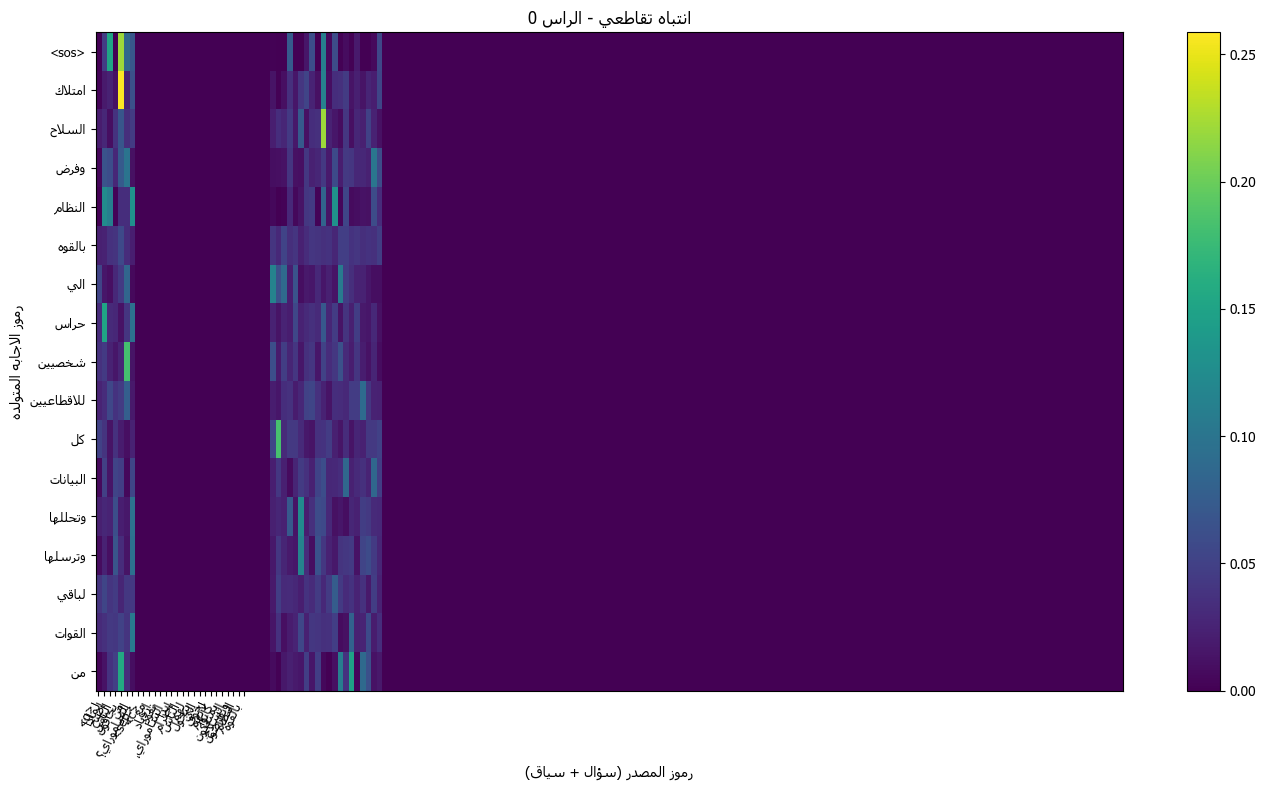

plotted validation sample index: 1


In [43]:
import random
import matplotlib.pyplot as plt
from matplotlib import font_manager, rcParams
import arabic_reshaper
from bidi.algorithm import get_display

def _pick_arabic_font():
    preferred = ["Tahoma", "Arial", "Segoe UI", "Amiri", "Noto Naskh Arabic"]
    available = {f.name for f in font_manager.fontManager.ttflist}
    for name in preferred:
        if name in available:
            return name
    return "DejaVu Sans"

AR_FONT = _pick_arabic_font()
rcParams["font.family"] = AR_FONT

def shape_arabic(text):
    return get_display(arabic_reshaper.reshape(str(text)))

def _compact_labels(tokens, max_labels=24, max_token_chars=16):
    if not tokens:
        return [], []

    stride = max(1, len(tokens) // max_labels)
    idx = list(range(0, len(tokens), stride))
    labels = []
    for i in idx:
        tok = tokens[i]
        if len(tok) > max_token_chars:
            tok = tok[: max_token_chars - 1] + "…"
        labels.append(shape_arabic(tok))
    return idx, labels

def plot_cross_attention(attn, src_tokens, tgt_tokens, head=0):
    a = attn[0, head].detach().cpu().numpy()

    plt.figure(figsize=(14, 8))
    plt.imshow(a, aspect="auto", cmap="viridis")

    x_idx, x_labels = _compact_labels(src_tokens, max_labels=26, max_token_chars=14)
    y_idx, y_labels = _compact_labels(tgt_tokens, max_labels=18, max_token_chars=14)

    plt.xticks(x_idx, x_labels, rotation=65, ha="right", fontsize=9)
    plt.yticks(y_idx, y_labels, fontsize=9)
    plt.xlabel(shape_arabic("رموز المصدر (سؤال + سياق)"))
    plt.ylabel(shape_arabic("رموز الاجابه المتولده"))
    plt.title(shape_arabic(f"انتباه تقاطعي - الراس {head}"))
    plt.colorbar()
    plt.tight_layout()
    plt.show()

# Pick a random validation sample so the graph can change from run to run.
sample_idx = random.randrange(len(val_ds))
q_ids, c_ids, _ = val_ds[sample_idx]
q_tag = torch.tensor([Q_IDX])
sep = torch.tensor([SEP_IDX])
c_tag = torch.tensor([C_IDX])
src_seq = torch.cat([q_tag, q_ids.long(), sep, c_tag, c_ids.long()], dim=0)[:MAX_SRC_LEN]

# Use generated answer tokens (not teacher-forced gold answer tokens).
pred_ids = greedy_decode(model, src_seq)
tgt_seq = torch.tensor(pred_ids, dtype=torch.long)[:MAX_TGT_LEN]
if tgt_seq.numel() == 0:
    tgt_seq = torch.tensor([SOS_IDX], dtype=torch.long)

src_ex = src_seq.unsqueeze(0).to(device)
tgt_ex = tgt_seq.unsqueeze(0).to(device)
_ = model(src_ex, tgt_ex)
attn = model.decoder.cross_attn.last_attention

src_toks = decode_ids(src_seq.tolist(), drop_special=False).split()
tgt_toks = decode_ids(tgt_seq.tolist(), drop_special=False).split()
plot_cross_attention(attn, src_toks, tgt_toks, head=0)
print(f"plotted validation sample index: {sample_idx}")

In [44]:
print(f"epochs_ran: {epochs_ran}")
print(f"best_val_loss: {best_val:.4f}")

epochs_ran: 40
best_val_loss: 5.7472
